# U3_S9 - Naive Bayes: Clasificación spam
Dataset: spam.csv (SMS Spam Collection)

Objetivo: A partir del ejercicio base visto en la sesión (clasificación de texto con GaussianNB), implementar MultinomialNB, interpretar las métricas obtenidas y comparar ambos modelos con gráficas de evaluación.



Nombre: Anthony Cruz Huacon

# **1. Importación de librerías**

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn. model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import  GaussianNB, MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_score, accuracy_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

print("Librerias importadas correctamente")



Librerias importadas correctamente


# **2. Carga y preparación de datos**

In [61]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')



In [62]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [63]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()



,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [64]:
df_nueva_data = df_nueva_data.rename(
    columns = {
        'v1': "categoria",
        'v2': "descripcion"
    }
)

df_nueva_data.head(5)



,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# **3. División en entrenamiento y prueba**

In [65]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']



In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)



# **4. Vectorización del texto**

In [67]:
vectorizador = CountVectorizer()

X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)



# **5. Modelo: GaussianNB**

In [68]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)



GaussianNB()

In [69]:
y_pred_g = gaussian.predict(X_test_vec.toarray())

print(y_pred_g)



['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [70]:
accuracy_g = accuracy_score(y_test, y_pred_g)
f1_g = f1_score(y_pred_g, y_test, pos_label = 'spam')
recall_g = recall_score(y_pred_g, y_test, pos_label = 'spam')
precision_g = precision_score(y_pred_g, y_test, pos_label='spam')
report_g = classification_report(y_test, y_pred_g, target_names = ['spam', 'ham'])

print("\n*************** Comparación de las métricas ***************")
print("Accuracy: ", accuracy_g)
print("Score: ", f1_g)
print("Recall: ", recall_g)
print("Precision: ", precision_g)
print("\nReporte de métricas: \n", report_g)




*************** Comparación de las métricas ***************
Accuracy:  0.9061004784688995
Score:  0.740495867768595
Recall:  0.6256983240223464
Precision:  0.9068825910931174

Reporte de métricas: 
               precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



In [71]:
report = classification_report(y_test, y_pred_g, target_names = ['spam', 'ham'])

print(report)



              precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



# **6. Modelo: MultinomialNB**

In [72]:
multinomial = MultinomialNB()

multinomial.fit(X_train_vec, y_train)

y_pred_m = multinomial.predict(X_test_vec)

print(y_pred_m)



['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [73]:
accuracy_m = accuracy_score(y_test, y_pred_m)
f1_m = f1_score(y_test, y_pred_m, pos_label='spam')
recall_m = recall_score(y_test, y_pred_m, pos_label='spam')
precision_m = precision_score(y_test, y_pred_m, pos_label='spam')
report_m = classification_report(y_test, y_pred_m, target_names = ['spam', 'ham'])

print("\n*************** Comparación de las métricas ***************")
print("Accuracy: ", accuracy_m)
print("Score: ",f1_m)
print("Recall: ", recall_m)
print("Precision: ", precision_m)
print("\nReporte de métricas: \n", report_m)




*************** Comparación de las métricas ***************
Accuracy:  0.9856459330143541
Score:  0.9504132231404959
Recall:  0.9311740890688259
Precision:  0.9704641350210971

Reporte de métricas: 
               precision    recall  f1-score   support

        spam       0.99      1.00      0.99      1425
         ham       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



# **7. Comparación de métricas: GaussianNB vs MultinomialNB**

In [74]:
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1-score (spam)'],
    'GaussianNB': [accuracy_g, precision_g, recall_g, f1_g],
    'MultinomialNB': [accuracy_m, precision_m, recall_m, f1_m]
})
comparacion['Diferencia (MNB - GNB)'] = comparacion['MultinomialNB'] - comparacion['GaussianNB']
comparacion



,Métrica,GaussianNB,MultinomialNB,Diferencia (MNB - GNB)
0,Accuracy,0.906100,0.985646,0.079545
1,Precision (spam),0.906883,0.970464,0.063582
2,Recall (spam),0.625698,0.931174,0.305476
3,F1-score (spam),0.740496,0.950413,0.209917


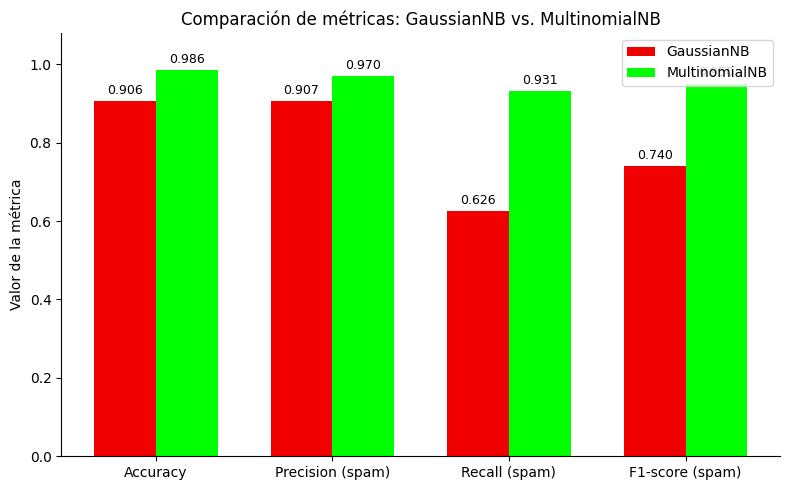

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))

metricas = comparacion['Métrica']
x = np.arange(len(metricas))
width = 0.35

barras_gnb = ax.bar(
    x - width/2, comparacion['GaussianNB'], width, label='GaussianNB', color='#f00000')
barras_mnb = ax.bar(
    x + width/2, comparacion['MultinomialNB'], width, label='MultinomialNB', color='#00ff00')

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas: GaussianNB vs. MultinomialNB')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.08)
ax.legend()
ax.bar_label(barras_gnb, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(barras_mnb, fmt='%.3f', padding=3, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



# **8. Matrices de confusión**

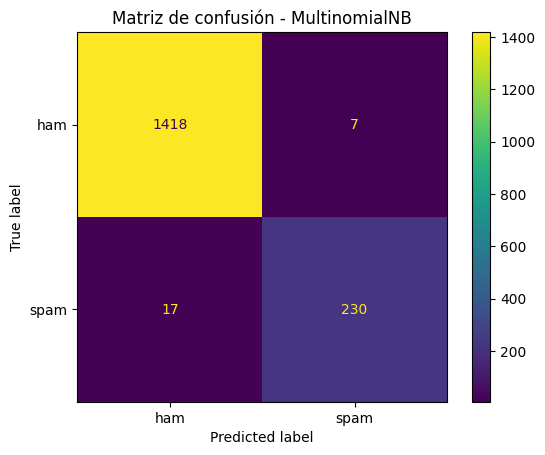

In [76]:
cm = confusion_matrix(
    y_test,
    y_pred_multi
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['ham','spam']
)

disp.plot()
plt.title("Matriz de confusión - MultinomialNB")
plt.show()



# **9. Curvas ROC**

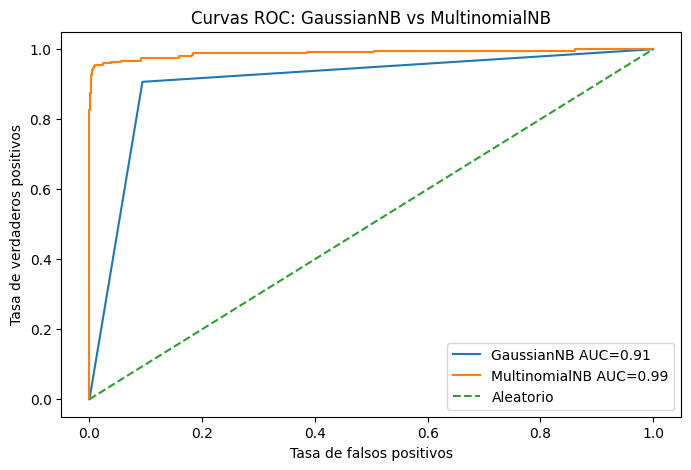

In [77]:
encoder = LabelEncoder()
y_test_num = encoder.fit_transform(y_test)

prob_gaussian = gaussian.predict_proba(X_test_vec.toarray())[:,1]

prob_multi = multinomial.predict_proba(X_test_vec)[:,1]

fpr_g, tpr_g, _ = roc_curve(y_test_num, prob_gaussian)

auc_g = auc(fpr_g, tpr_g)

fpr_m, tpr_m, _ = roc_curve(y_test_num, prob_multi)

auc_m = auc(fpr_m, tpr_m)

plt.figure(figsize=(8,5))

plt.plot(fpr_g, tpr_g, label=f"GaussianNB AUC={auc_g:.2f}")

plt.plot(fpr_m, tpr_m, label=f"MultinomialNB AUC={auc_m:.2f}")


plt.plot([0,1], [0,1], linestyle="--", label="Aleatorio")


plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title("Curvas ROC: GaussianNB vs MultinomialNB")

plt.legend()

plt.show()



# **10. Interpretación de resultados**

Los resultados obtenidos permiten comparar el comportamiento de GaussianNB y MultinomialNB en la clasificación de mensajes. Aunque ambos modelos utilizan el algoritmo Naive Bayes, MultinomialNB presenta mejores resultados porque está diseñado para trabajar con datos de texto representados mediante frecuencia de palabras. La matriz de confusión y la curva ROC ayudan a comprobar que el modelo propuesto tiene una mayor capacidad para identificar correctamente mensajes spam y reducir errores de clasificación.